# Stage 2 — Profile Comparison

Loads the pre-trained UserProfiler and embeds four profiles:
- **Ahmed** — personal survey + Google Maps Takeout history
- **Budget Solo Backpacker** — survey only
- **Upscale Couple** — survey only
- **Family with Kids** — survey only

**Prerequisites:** run `02_stage2_demo.ipynb` first to generate `artifacts/user_profiler.joblib`.

In [1]:
import importlib.util, subprocess, sys

_NEEDED = [
    ("joblib",       "joblib"),
    ("scipy",        "scipy"),
    ("scikit-learn", "sklearn"),
]
for pip_name, import_name in _NEEDED:
    if importlib.util.find_spec(import_name) is None:
        print(f"Installing {pip_name} …")
        subprocess.run([sys.executable, "-m", "pip", "install", pip_name, "-q"], check=True)
    else:
        print(f"{pip_name} already present — skipping")

import os, json, logging
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.decomposition import PCA

REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), "../.."))
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

logging.basicConfig(level=logging.INFO, format="%(levelname)s  %(message)s")

from ml.models.user_profiler import UserProfiler
from ml.utilities.embeddings import cosine_similarity

ARTIFACT_PATH = os.path.join(REPO_ROOT, "artifacts", "user_profiler.joblib")
profiler = UserProfiler.load(ARTIFACT_PATH)
print(f"Profiler loaded — trained on {profiler._n_trained_users:,} users")

joblib already present — skipping
scipy already present — skipping
scikit-learn already present — skipping


INFO  UserProfiler loaded from /Users/ahmedabdelsalam/Desktop/PlanIt/planit/artifacts/user_profiler.joblib


Profiler loaded — trained on 50,000 users


In [2]:
# Ahmed's survey response
MY_PREFERENCE = {
    "user_id": "ahmed_demo",

    "use_case":   "travel",
    "part_type":  "couple",

    "daily_budget_tier": 3,
    "trip_budget_tier":  3,

    "preferred_tags": ["cultural", "food_and_drink", "outdoor", "historical", "scenic"],
    "exploration_score": 4,
    "popularity_weight": 3,

    "cuisine_preferences":  ["italian", "east asian", "mediterranean"],
    "dietary_restrictions": [],

    "travel_mode":        ["walk", "transit"],
    "max_travel_minutes": "20-40",
    "itinerary_pace":     "balanced",
}

print("Survey defined.")

Survey defined.


In [3]:
from ml.models.user_profiler import parse_google_reviews, parse_google_saved_places

TAKEOUT_FOLDER = "/Users/ahmedabdelsalam/Downloads/Myplaces"

GMAPS_REVIEWS_PATH      = os.path.join(TAKEOUT_FOLDER, "Reviews.json")
GMAPS_SAVED_PLACES_PATH = os.path.join(TAKEOUT_FOLDER, "Saved Places.json")

my_visits = []

if os.path.exists(GMAPS_REVIEWS_PATH):
    with open(GMAPS_REVIEWS_PATH, encoding="utf-8") as f:
        reviews_data = json.load(f)
    review_visits = parse_google_reviews(reviews_data, user_id=MY_PREFERENCE["user_id"])
    my_visits.extend(review_visits)
    print(f"Reviews.json      : {len(review_visits)} rated places loaded")
else:
    print(f"Reviews.json not found at {GMAPS_REVIEWS_PATH}")

if os.path.exists(GMAPS_SAVED_PLACES_PATH):
    with open(GMAPS_SAVED_PLACES_PATH, encoding="utf-8") as f:
        saved_data = json.load(f)
    saved_visits = parse_google_saved_places(saved_data, user_id=MY_PREFERENCE["user_id"])
    my_visits.extend(saved_visits)
    print(f"Saved Places.json : {len(saved_visits)} saved places loaded")
else:
    print(f"Saved Places.json not found at {GMAPS_SAVED_PLACES_PATH}")

print(f"\nTotal personal visit records : {len(my_visits)}")

if my_visits:
    my_tag_counts = Counter(t for v in my_visits for t in v.get("tags", []))
    print("\nTop place categories from Maps history:")
    for tag, cnt in my_tag_counts.most_common(8):
        bar = "█" * cnt
        print(f"  {tag:<20} {bar} ({cnt})")

    rated      = [v for v in my_visits if v.get("rating") is not None]
    avg_rating = sum(v["rating"] for v in rated) / len(rated) if rated else 0
    print(f"\n  Avg rating : {avg_rating:.2f} / 5.0  ({len(rated)} rated places)")

INFO  Parsed 42 places from Google Maps Reviews.json for user ahmed_demo
INFO  Parsed 4 places from Google Maps Saved Places.json for user ahmed_demo


Reviews.json      : 42 rated places loaded
Saved Places.json : 4 saved places loaded

Total personal visit records : 46

Top place categories from Maps history:
  food_and_drink       █████████████████ (17)
  quick_visit          █████████ (9)
  outdoor              █████████ (9)
  scenic               ████████ (8)
  pet_friendly         ███████ (7)
  wellness             ████ (4)
  adventurous          ███ (3)
  nightlife            ███ (3)

  Avg rating : 4.43 / 5.0  (46 rated places)


In [4]:
# Embed Ahmed with survey + Takeout history
my_embedding = profiler.embed_user(
    preference=MY_PREFERENCE,
    visits=my_visits or None,
)

print(f"Embedding shape : {my_embedding.shape}")
print(f"L2 norm         : {np.linalg.norm(my_embedding):.4f}  (should be ~1.0)")
print(f"\nTop 10 active dimensions:")
top_dims = np.argsort(np.abs(my_embedding))[::-1][:10]
for dim in top_dims:
    print(f"  dim[{dim:>2}] = {my_embedding[dim]:+.4f}")

Embedding shape : (64,)
L2 norm         : 1.0000  (should be ~1.0)

Top 10 active dimensions:
  dim[ 0] = +0.8564
  dim[ 2] = +0.2503
  dim[ 1] = +0.2281
  dim[ 3] = +0.2085
  dim[ 4] = +0.1773
  dim[ 6] = +0.1259
  dim[ 8] = +0.0814
  dim[ 7] = -0.0757
  dim[11] = +0.0657
  dim[16] = +0.0657


In [5]:
# Find Ahmed's most similar users in the trained corpus
similar = profiler.find_similar_users(my_embedding, top_k=10)

print("Top 10 most similar users (user_id, cosine similarity):")
print(f"{'Rank':<5} {'User ID':<35} {'Similarity':>10}")
print("-" * 52)
for rank, (uid, score) in enumerate(similar, 1):
    print(f"{rank:<5} {uid:<35} {score:>10.4f}")

Top 10 most similar users (user_id, cosine similarity):
Rank  User ID                             Similarity
----------------------------------------------------
1     249427                                  0.9610
2     55549                                   0.9556
3     26537                                   0.9528
4     253051                                  0.9519
5     164135                                  0.9517
6     111051                                  0.9493
7     80861                                   0.9489
8     136074                                  0.9487
9     138470                                  0.9481
10    11454                                   0.9471


In [6]:
# Three comparison profiles — survey only, no visit history
COMPARISON_PROFILES = [
    {
        "label": "Budget Solo Backpacker",
        "color": "steelblue",
        "preference": {
            "user_id":             "backpacker_01",
            "use_case":            "travel",
            "part_type":           "solo",
            "daily_budget_tier":   1,
            "trip_budget_tier":    1,
            "preferred_tags":      ["adventurous", "outdoor", "budget_friendly", "historical", "scenic"],
            "exploration_score":   5,
            "popularity_weight":   1,
            "cuisine_preferences": ["southeast asian", "mexican", "indian"],
            "dietary_restrictions": [],
            "travel_mode":         ["walk", "transit"],
            "max_travel_minutes":  "> 40",
            "itinerary_pace":      "packed",
        },
    },
    {
        "label": "Upscale Couple",
        "color": "crimson",
        "preference": {
            "user_id":             "couple_01",
            "use_case":            "travel",
            "part_type":           "couple",
            "daily_budget_tier":   4,
            "trip_budget_tier":    4,
            "preferred_tags":      ["romantic", "upscale", "food_and_drink", "cultural", "scenic"],
            "exploration_score":   2,
            "popularity_weight":   5,
            "cuisine_preferences": ["italian", "mediterranean", "seafood"],
            "dietary_restrictions": [],
            "travel_mode":         ["drive"],
            "max_travel_minutes":  "10-20",
            "itinerary_pace":      "relaxed",
        },
    },
    {
        "label": "Family with Kids",
        "color": "seagreen",
        "preference": {
            "user_id":             "family_01",
            "use_case":            "daytrip",
            "part_type":           "family",
            "daily_budget_tier":   2,
            "trip_budget_tier":    2,
            "preferred_tags":      ["family_friendly", "outdoor", "quick_visit", "food_and_drink", "pet_friendly"],
            "exploration_score":   2,
            "popularity_weight":   4,
            "cuisine_preferences": ["american", "italian", "mexican"],
            "dietary_restrictions": ["nut_allergy"],
            "travel_mode":         ["drive"],
            "max_travel_minutes":  "10-20",
            "itinerary_pace":      "balanced",
        },
    },
]

for p in COMPARISON_PROFILES:
    p["embedding"] = profiler.embed_user(preference=p["preference"], visits=None)

print("Profiles embedded.")

Profiles embedded.


In [7]:
# Pairwise cosine similarity — Ahmed vs each comparison profile
print("Cosine similarity — Ahmed vs comparison profiles:\n")
for p in COMPARISON_PROFILES:
    sim = cosine_similarity(my_embedding, p["embedding"])
    print(f"  Ahmed  ↔  {p['label']:<28}  {sim:.4f}")

print()
print("Cosine similarity — between comparison profiles:\n")
for i in range(len(COMPARISON_PROFILES)):
    for j in range(i + 1, len(COMPARISON_PROFILES)):
        a, b = COMPARISON_PROFILES[i], COMPARISON_PROFILES[j]
        sim = cosine_similarity(a["embedding"], b["embedding"])
        print(f"  {a['label']:<28}  ↔  {b['label']:<28}  {sim:.4f}")

Cosine similarity — Ahmed vs comparison profiles:

  Ahmed  ↔  Budget Solo Backpacker        0.2573
  Ahmed  ↔  Upscale Couple                0.2390
  Ahmed  ↔  Family with Kids              0.3468

Cosine similarity — between comparison profiles:

  Budget Solo Backpacker        ↔  Upscale Couple                0.1664
  Budget Solo Backpacker        ↔  Family with Kids              0.1741
  Upscale Couple                ↔  Family with Kids              0.3332


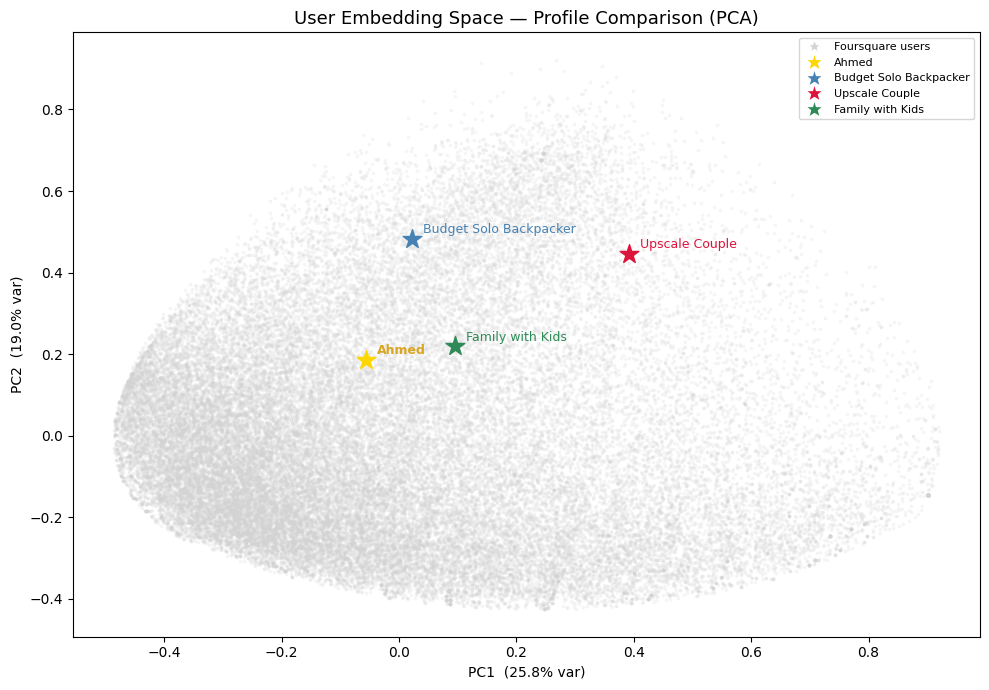

Saved to /Users/ahmedabdelsalam/Desktop/PlanIt/planit/artifacts/stage2_profile_comparison.png


In [8]:
# PCA — all trained users + Ahmed + 3 comparison profiles
pca    = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(profiler._user_embeddings)

ahmed_coords = pca.transform(my_embedding[np.newaxis])[0]

fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(coords[:, 0], coords[:, 1],
           s=3, alpha=0.15, color="lightgrey", label="Foursquare users")

# Ahmed
ax.scatter(*ahmed_coords, s=200, color="gold", zorder=6, marker="*")
ax.annotate("Ahmed", ahmed_coords, textcoords="offset points",
            xytext=(8, 4), fontsize=9, color="goldenrod", fontweight="bold")

# Comparison profiles
for p in COMPARISON_PROFILES:
    pt = pca.transform(p["embedding"][np.newaxis])[0]
    ax.scatter(*pt, s=200, color=p["color"], zorder=5, marker="*")
    ax.annotate(p["label"], pt, textcoords="offset points",
                xytext=(8, 4), fontsize=9, color=p["color"])

ax.set_title("User Embedding Space — Profile Comparison (PCA)", fontsize=13)
ax.set_xlabel(f"PC1  ({pca.explained_variance_ratio_[0]*100:.1f}% var)")
ax.set_ylabel(f"PC2  ({pca.explained_variance_ratio_[1]*100:.1f}% var)")

from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0],[0], marker="*", color="w", markerfacecolor="lightgrey", markersize=10, label="Foursquare users"),
    Line2D([0],[0], marker="*", color="w", markerfacecolor="gold",      markersize=14, label="Ahmed"),
] + [
    Line2D([0],[0], marker="*", color="w", markerfacecolor=p["color"],  markersize=14, label=p["label"])
    for p in COMPARISON_PROFILES
]
ax.legend(handles=legend_handles, loc="upper right", fontsize=8)

plt.tight_layout()
OUT = os.path.join(REPO_ROOT, "artifacts", "stage2_profile_comparison.png")
plt.savefig(OUT, dpi=150)
plt.show()
print(f"Saved to {OUT}")